In [161]:
from pathlib import Path

import duckdb as db
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.linear_model import LinearRegression

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

# Detect project root robustly.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
RAW_DIR = DATA_DIR / "raw"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"

PARQUET_PATH_ALL = PROCESSED_DIR / "crimes_clean_dedup_all_years.parquet"
PARQUET_SQL_PATH_ALL = PARQUET_PATH_ALL.as_posix()

PARQUET_PATH_FILTERED = PROCESSED_DIR / "crimes_filtered_for_model.parquet"
PARQUET_SQL_PATH_FILTERED = PARQUET_PATH_FILTERED.as_posix()

HOME_OFFICE_TYPE_CRIME_COUNTS = RAW_DIR / "prc-pfa-mar2013-onwards-tables-230426.ods"


# true to output the figures
EXPORT_OUTPUTS = False

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Crime parquet path: {PARQUET_PATH_ALL}")
print(f"Parquet exists: {PARQUET_PATH_ALL.exists()}")
print(f"Filtered parquet path: {PARQUET_PATH_FILTERED}")
print(f"Filtered parquet exists: {PARQUET_PATH_FILTERED.exists()}")

if not PARQUET_PATH_ALL.exists():
    raise FileNotFoundError(
        "Could not find crimes_clean_dedup_all_years.parquet. "
        "Expected it under data/processed/."
    )

if not PARQUET_PATH_FILTERED.exists():
    raise FileNotFoundError(
        "Could not find crimes_filtered_for_model.parquet. "
        "Expected it under data/processed/."
    )

Project root: /home/rovsi/Courses/Multidisciplinary_CBL
Crime parquet path: /home/rovsi/Courses/Multidisciplinary_CBL/data/processed/crimes_clean_dedup_all_years.parquet
Parquet exists: True
Filtered parquet path: /home/rovsi/Courses/Multidisciplinary_CBL/data/processed/crimes_filtered_for_model.parquet
Filtered parquet exists: True


In [162]:
df_crime_costs = pd.read_csv(RAW_DIR / "Crime_Response_Costs.csv")#.set_index("crime_type")
df_crime_costs

,crime_type,avg_gbp,lower_quartile_gbp,upper_quartile_gbp
0,Homicide,575000,232270,782050
1,Death or serious injury caused by unlawful dri...,60040,33380,75730
2,Trafficking of drugs,6610,4880,10590
3,Rape,5040,3380,6690
4,Other sexual offences,3050,2480,3920
5,Possession of weapons offences,2280,1400,2900
6,Robbery,2070,1670,3610
7,Miscellaneous crimes,1520,1090,1870
8,Possession of drugs,1260,1080,1770
9,Violence with injury,1250,1080,1550


In [163]:
df_crime_type_distribution = db.sql(f"""
    SELECT
        "Crime type" AS crime_type,
        COUNT(*) AS n,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct
    FROM read_parquet('{PARQUET_SQL_PATH_ALL}') AS crimes
    GROUP BY "Crime type"
    ORDER BY pct DESC
""").df()

#Police.uk data crime types
df_crime_type_distribution["crime_type"]

0            Anti-social behaviour
1     Violence and sexual offences
2        Criminal damage and arson
3                      Other theft
4                    Vehicle crime
5                         Burglary
6                     Public order
7                      Other crime
8                      Shoplifting
9                            Drugs
10                   Violent crime
11                         Robbery
12                   Bicycle theft
13           Theft from the person
14           Possession of weapons
15     Public disorder and weapons
Name: crime_type, dtype: str

# Creating a mapping: 

In [164]:
# Official Mapping from police.uk categories to Home Office crime types
df_category_mapping = pd.read_csv(RAW_DIR / "police-uk-category-mappings.csv", encoding="cp1252")[["Sub Class", "Police.uk Category"]]
df_category_mapping["Sub Class"] = df_category_mapping["Sub Class"].str.lower()
df_category_mapping = df_category_mapping.drop_duplicates()
df_category_mapping.sort_values("Police.uk Category", inplace=True)
df_category_mapping["nunique subclass"] = df_category_mapping.duplicated(subset=["Sub Class"], keep=False)
df_category_mapping.dropna(inplace=True)
df_category_mapping.reset_index(drop=True, inplace=True)
df_category_mapping

# df_crime_costs["crime_type"] = df_crime_costs["crime_type"].str.lower()
# df_category_mapping = df_category_mapping.merge(df_crime_costs, how="left", left_on="Sub Class", right_on="crime_type")
# df_category_mapping.dropna(subset=["crime_type"], inplace=True)
# df_category_mapping.reset_index(drop=True, inplace=True)
# df_category_mapping

,Sub Class,Police.uk Category,nunique subclass
0,bicycle theft,Bicycle Theft,False
1,burglary residential,Burglary,False
2,burglary business and community,Burglary,False
3,business and community,Burglary,False
4,arson,Criminal Damage and Arson,False
5,criminal damage,Criminal Damage and Arson,True
6,trafficking of drugs,Drugs,False
7,possession of drugs,Drugs,False
8,,Other Crime,False
9,criminal damage,Other Crime,True


In [165]:
df_crime_costs["crime_type"] 

0                                              Homicide
1     Death or serious injury caused by unlawful dri...
2                                  Trafficking of drugs
3                                                  Rape
4                                 Other sexual offences
5                        Possession of weapons offences
6                                               Robbery
7                                  Miscellaneous crimes
8                                   Possession of drugs
9                                  Violence with injury
10                                    Domestic burglary
11                                                Arson
12                                Non-domestic burglary
13                                Theft from the person
14                                     Vehicle offences
15                              Violence without injury
16                                          Shoplifting
17                                 Other theft o

In [166]:
HOME_OFFICE_TYPE_CRIME_COUNTS_PARQUET = PROCESSED_DIR / "home_office_offences.parquet"
HOME_OFFICE_TYPE_CRIME_COUNTS_PARQUET_SQL = HOME_OFFICE_TYPE_CRIME_COUNTS_PARQUET.as_posix()

db.sql(f"""
SELECT * EXCLUDE ("filename", "Offence Description_1", "Offence Group_1", "Offence Subgroup_1")
FROM read_parquet('{HOME_OFFICE_TYPE_CRIME_COUNTS_PARQUET_SQL}')
LIMIT 1000
""").df()["Offence Subgroup"].unique()

<ArrowStringArray>
[      'Miscellaneous crimes against society',
                      'Other sexual offences',
                   'Non-residential burglary',
                      'Non-domestic burglary',
                          'Domestic burglary',
                       'Residential burglary',
                           'Vehicle offences',
                                      'Arson',
                       'Violence with injury',
                    'Violence without injury',
                       'Other theft offences',
 'Death or serious injury - unlawful driving',
                    'Stalking and harassment',
                                   'Homicide',
                            'Criminal damage',
                        'Possession of drugs',
             'Possession of weapons offences',
                      'Public order offences',
                              'Rape offences',
               'Robbery of business property',
               'Robbery of personal prope

In [167]:
db.sql(f"""
SELECT *
FROM read_parquet('{HOME_OFFICE_TYPE_CRIME_COUNTS_PARQUET_SQL}')
WHERE "Number of Offences" = 'N/a'
""").df()

,Financial Year,Financial Quarter,Force Name,Offence Description,Offence Group,Offence Subgroup,Offence Code,Number of Offences,Offence Description_1,Offence Group_1,Offence Subgroup_1,filename
0,2025/26,3,Action Fraud,Fraud offences recorded by Action Fraud,Fraud offences,Fraud: Action Fraud,AF,N/a,None,None,None,/home/rovsi/Courses/Multidisciplinary_CBL/data...
1,2025/26,3,CIFAS,Fraud offences recorded by CIFAS,Fraud offences,Fraud: CIFAS,CIFAS,N/a,None,None,None,/home/rovsi/Courses/Multidisciplinary_CBL/data...
2,2025/26,3,UK Finance,Fraud offences recorded by UK Finance,Fraud offences,Fraud: UK Finance,UK Finance,N/a,None,None,None,/home/rovsi/Courses/Multidisciplinary_CBL/data...


In [168]:
#All Time (Excluding Covid) Sum of Offences by Force and Offence Subgroup (Excluding Fraud)

db.sql(f"""
SELECT
    "Force Name", 
    "Offence Subgroup",
    SUM(
        CAST(REPLACE("Number of Offences", '.', '') AS BIGINT)
        ) AS total_offences
FROM read_parquet('{HOME_OFFICE_TYPE_CRIME_COUNTS_PARQUET_SQL}')
WHERE 
    "Financial Year" NOT IN ('2019/20', '2020/21', '2021/22') AND
    "Offence Group" != 'Fraud offences'
GROUP BY "Force Name", "Offence Subgroup"
""").df()

,Force Name,Offence Subgroup,total_offences
0,Cambridgeshire,Robbery of business property,446.0
1,Cheshire,Violence without injury,99668.0
2,Cheshire,Other theft offences,68454.0
3,Cheshire,Homicide,62.0
4,Cleveland,Death or serious injury - unlawful driving,115.0
...,...,...,...
1095,Kent,Non-residential burglary,12988.0
1096,Lancashire,Residential burglary,34591.0
1097,Northamptonshire,Residential burglary,14941.0
1098,Nottinghamshire,Non-residential burglary,10035.0


In [169]:
OUTPUT_PARQUET = PROCESSED_DIR / "ho_force_subgroup_totals.parquet"
#Formatting Issues with the "Number of Offences" column (e.g. 'N/a' and numbers with commas) mean we have to do some cleaning in SQL before we can aggregate. We also exclude the Covid years and Fraud offences as they are outliers in terms of trends and volumes respectively.

db.sql(f"""
COPY (
    SELECT
        "Force Name",
        "Offence Subgroup",
        SUM(
            CAST(REPLACE("Number of Offences", '.', '') AS BIGINT)
        ) AS total_offences
    FROM read_parquet('{HOME_OFFICE_TYPE_CRIME_COUNTS_PARQUET_SQL}')
    WHERE
        "Financial Year" NOT IN ('2019/20', '2020/21', '2021/22')
        AND "Offence Group" != 'Fraud offences'
    GROUP BY
        "Force Name",
        "Offence Subgroup"
)
TO '{OUTPUT_PARQUET}'
(FORMAT PARQUET, COMPRESSION ZSTD);
""")

In [170]:
db.sql(f"""
SELECT

    "Offence Subgroup",
    SUM(
        CAST(REPLACE("Number of Offences", '.', '') AS BIGINT)
        ) AS total_offences
FROM read_parquet('{HOME_OFFICE_TYPE_CRIME_COUNTS_PARQUET_SQL}')
WHERE 
    "Financial Year" NOT IN ('2019/20', '2020/21', '2021/22') AND
    "Offence Group" != 'Fraud offences'
GROUP BY "Offence Subgroup"
""").df()
#All Time (Excluding Covid) Sum of Offences by Offence Subgroup (Excluding Fraud)

,Offence Subgroup,total_offences
0,Robbery of business property,100036.0
1,Residential burglary,1260024.0
2,Shoplifting,4110972.0
3,Non-residential burglary,553594.0
4,Death or serious injury - unlawful driving,11245.0
5,Criminal damage,5398809.0
6,Rape offences,524384.0
7,Bicycle theft,918257.0
8,Domestic burglary,1036527.0
9,Possession of drugs,1486352.0


<!-- Trying a mapping with aggregation based on the ratio of sub home office groups -->

## Trying a mapping to police.uk category to its home office subgroups

In [171]:
violent_subgroups = [
    "Homicide",
    "Violence with injury",
    "Violence without injury",
]

In [172]:
query = f"""
WITH clean AS (
    SELECT
        "Force Name" AS force_name,
        "Financial Year" AS financial_year,
        "Offence Subgroup" AS offence_subgroup,
        CAST(REPLACE("Number of Offences", '.', '') AS BIGINT) AS offences
    FROM read_parquet('{HOME_OFFICE_TYPE_CRIME_COUNTS_PARQUET_SQL}')
    WHERE "Offence Subgroup" IN (
        'Homicide',
        'Violence with injury',
        'Violence without injury'
    )
    AND "Financial Year" NOT IN ('2019/20', '2020/21', '2021/22')
),

agg AS (
    SELECT
        force_name,
        financial_year,
        SUM(CASE WHEN offence_subgroup = 'Homicide'
                 THEN offences ELSE 0 END) AS homicide,
        SUM(CASE WHEN offence_subgroup IN (
                    'Homicide',
                    'Violence with injury',
                    'Violence without injury'
                 )
                 THEN offences ELSE 0 END) AS violent_total
    FROM clean
    GROUP BY force_name, financial_year
)

SELECT
    force_name,
    financial_year,
    homicide,
    violent_total,
    homicide * 100.0 / violent_total AS homicide_pct
FROM agg
WHERE violent_total > 0
ORDER BY force_name, financial_year
"""

df = db.sql(query).df()

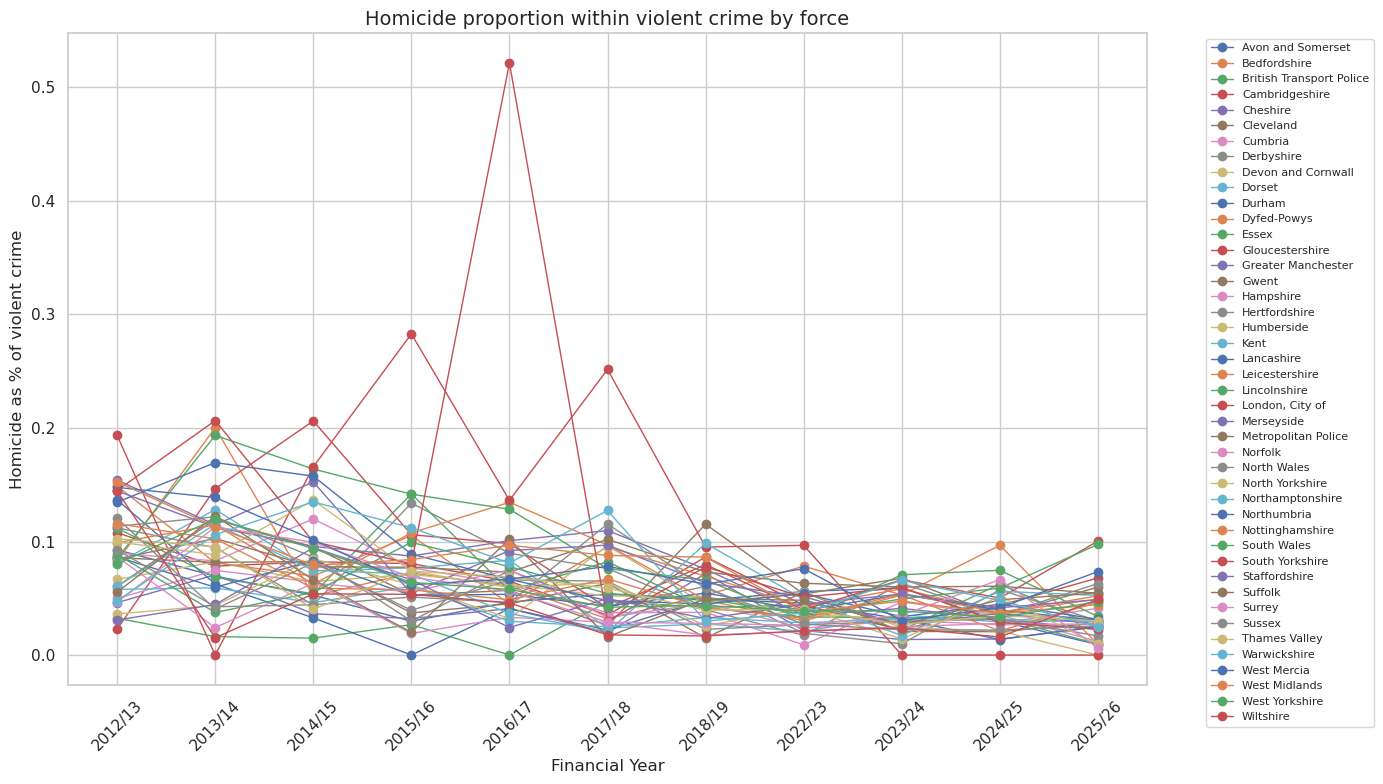

In [173]:
plt.figure(figsize=(14, 8))

for force in df["force_name"].unique():
    temp = df[df["force_name"] == force]

    plt.plot(
        temp["financial_year"],
        temp["homicide_pct"],
        marker="o",
        linewidth=1,
        label=force
    )

plt.ylabel("Homicide as % of violent crime")
plt.xlabel("Financial Year")
plt.title("Homicide proportion within violent crime by force")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

In [174]:
force_summary = (
    df.groupby("force_name")
    .agg(
        avg_homicide_pct=("homicide_pct", "mean"),
        std_homicide_pct=("homicide_pct", "std"),
        total_homicide=("homicide", "sum"),
        total_violent=("violent_total", "sum")
    )
    .assign(overall_homicide_pct=lambda x: x["total_homicide"] * 100 / x["total_violent"])
    .sort_values("overall_homicide_pct", ascending=False)
)

force_summary

,avg_homicide_pct,std_homicide_pct,total_homicide,total_violent,overall_homicide_pct
force_name,,,,,
South Yorkshire,0.120265,0.144001,265.0,263276.0,0.100655
"London, City of",0.111066,0.104635,9.0,9392.0,0.095826
Lincolnshire,0.096841,0.052717,89.0,110866.0,0.080277
Gloucestershire,0.087056,0.053539,68.0,89393.0,0.076069
Metropolitan Police,0.075321,0.016120,1240.0,1678788.0,0.073863
West Mercia,0.079887,0.036463,147.0,204188.0,0.071992
Warwickshire,0.074072,0.040298,60.0,87531.0,0.068547
Greater Manchester,0.077862,0.039956,440.0,649675.0,0.067726
Bedfordshire,0.071790,0.048974,72.0,107049.0,0.067259


In [175]:
force_summary["overall_homicide_pct"].describe()


count    44.000000
mean      0.055601
std       0.015430
min       0.032318
25%       0.046513
50%       0.051352
75%       0.064494
max       0.100655
Name: overall_homicide_pct, dtype: float64

In [176]:
db.sql(f"""
SELECT
    "Offence Subgroup",
    SUM(CAST(REPLACE("Number of Offences", '.', '') AS BIGINT)) AS offences
FROM read_parquet('{HOME_OFFICE_TYPE_CRIME_COUNTS_PARQUET_SQL}')
WHERE "Force Name" = 'South Yorkshire'
  AND "Financial Year" = '2016/17'
  AND "Offence Subgroup" IN (
        'Homicide',
        'Violence with injury',
        'Violence without injury'
  )
GROUP BY "Offence Subgroup"
""").df()

,Offence Subgroup,offences
0,Violence with injury,12557.0
1,Violence without injury,8999.0
2,Homicide,113.0


# Excluding the stadium tragedy:

In [177]:


in_path = HOME_OFFICE_TYPE_CRIME_COUNTS_PARQUET_SQL
CORRECTED_HOME_OFFICE_TYPE_CRIME_COUNTS_PARQUET_SQL = Path("/home/rovsi/Courses/Multidisciplinary_CBL/data/processed/home_office_offences_corrected.parquet").as_posix()

db.sql(f"""
COPY (
    SELECT
        * REPLACE (
            CASE
                WHEN "Force Name" = 'South Yorkshire'
                 AND "Financial Year" = '2016/17'
                 AND "Offence Subgroup" = 'Homicide'
                THEN '17'
                ELSE "Number of Offences"
            END AS "Number of Offences"
        )
    FROM read_parquet('{HOME_OFFICE_TYPE_CRIME_COUNTS_PARQUET_SQL}')
)
TO '{CORRECTED_HOME_OFFICE_TYPE_CRIME_COUNTS_PARQUET_SQL}'
(FORMAT PARQUET, COMPRESSION ZSTD, OVERWRITE_OR_IGNORE TRUE);
""")

In [178]:
#All Time (Excluding Covid) Sum of Offences by Force and Offence Subgroup (Excluding Fraud)

df_year_force_subgroup_n = db.sql(f"""
SELECT
    "Financial Year",
    "Force Name", 
    "Offence Subgroup",
    SUM(
        CAST(REPLACE("Number of Offences", '.', '') AS BIGINT)
        ) AS total_offences
FROM read_parquet('{HOME_OFFICE_TYPE_CRIME_COUNTS_PARQUET_SQL}')
WHERE 
    "Financial Year" NOT IN ('2019/20', '2020/21', '2021/22') AND
    "Offence Group" != 'Fraud offences'
GROUP BY "Financial Year", "Force Name", "Offence Subgroup"
""").df()

In [179]:
mask = (
    (df_year_force_subgroup_n["Offence Subgroup"] == "Homicide") &
    (df_year_force_subgroup_n["Force Name"] == "South Yorkshire") &
    (df_year_force_subgroup_n["Financial Year"] == "2016/17")
)

df_year_force_subgroup_n.loc[mask, "total_offences"] = 17
df_year_force_subgroup_n.to_parquet(PROCESSED_DIR / "year_force_subgroup_n.parquet", index=False, compression="zstd")

In [180]:
df_year_force_subgroup_n.head()

,Financial Year,Force Name,Offence Subgroup,total_offences
0,2016/17,Cambridgeshire,Bicycle theft,3789.0
1,2016/17,Cheshire,Violence without injury,6487.0
2,2016/17,Cheshire,Other theft offences,6210.0
3,2016/17,Cheshire,Homicide,6.0
4,2016/17,Cleveland,Possession of drugs,1073.0


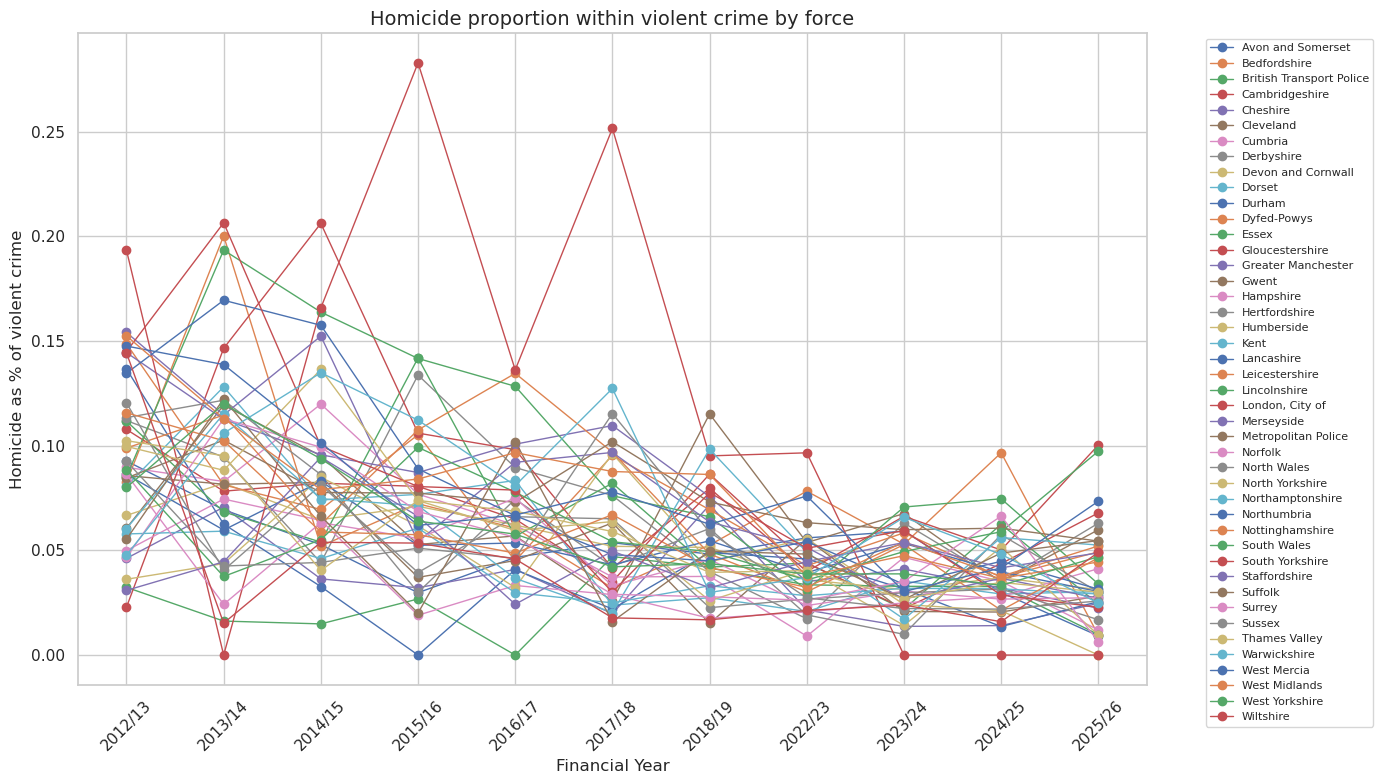

In [181]:

violent_cats = [
    "Homicide",
    "Violence with injury",
    "Violence without injury"
]

df_violent = df_year_force_subgroup_n[
    df_year_force_subgroup_n["Offence Subgroup"].isin(violent_cats)
].copy()

df_homicide_ratio = (
    df_violent
    .groupby(["Financial Year", "Force Name"])
    .apply(lambda g: g.loc[g["Offence Subgroup"] == "Homicide", "total_offences"].sum()
          / g["total_offences"].sum() * 100)
    .reset_index(name="homicide_pct")
)

plt.figure(figsize=(14, 8))

for force in df_homicide_ratio["Force Name"].unique():
    temp = df_homicide_ratio[df_homicide_ratio["Force Name"] == force]
    plt.plot(
        temp["Financial Year"],
        temp["homicide_pct"],
        marker="o",
        linewidth=1,
        label=force
    )

plt.title("Homicide proportion within violent crime by force")
plt.xlabel("Financial Year")
plt.ylabel("Homicide as % of violent crime")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

In [182]:
violent_cats = [
    "Homicide",
    "Violence with injury",
    "Violence without injury"
]

df_violent = df_year_force_subgroup_n[
    df_year_force_subgroup_n["Offence Subgroup"].isin(violent_cats)
].copy()

force_totals = (
    df_violent
    .groupby("Force Name")
    .apply(
        lambda g: pd.Series({
            "total_homicide":
                g.loc[
                    g["Offence Subgroup"] == "Homicide",
                    "total_offences"
                ].sum(),

            "total_violent":
                g["total_offences"].sum()
        })
    )
)

force_summary = (
    df_homicide_ratio
    .groupby("Force Name")
    .agg(
        avg_homicide_pct=("homicide_pct", "mean"),
        std_homicide_pct=("homicide_pct", "std")
    )
    .join(force_totals)
)

force_summary["overall_homicide_pct"] = (
    100
    * force_summary["total_homicide"]
    / force_summary["total_violent"]
)

force_summary = force_summary.sort_values(
    "overall_homicide_pct",
    ascending=False
)

force_summary

,avg_homicide_pct,std_homicide_pct,total_homicide,total_violent,overall_homicide_pct
Force Name,,,,,
"London, City of",0.111066,0.104635,9.0,9392.0,0.095826
Lincolnshire,0.096841,0.052717,89.0,110866.0,0.080277
Gloucestershire,0.087056,0.053539,68.0,89393.0,0.076069
Metropolitan Police,0.075321,0.016120,1240.0,1678788.0,0.073863
West Mercia,0.079887,0.036463,147.0,204188.0,0.071992
Warwickshire,0.074072,0.040298,60.0,87531.0,0.068547
Greater Manchester,0.077862,0.039956,440.0,649675.0,0.067726
Bedfordshire,0.071790,0.048974,72.0,107049.0,0.067259
West Midlands,0.078682,0.035650,410.0,621683.0,0.065950


In [183]:
force_summary["overall_homicide_pct"].describe()

count    44.000000
mean      0.054772
std       0.013853
min       0.032318
25%       0.046513
50%       0.051352
75%       0.064280
max       0.095826
Name: overall_homicide_pct, dtype: float64

In [184]:
df_force_subgroup_n = db.sql(f"""
SELECT
    "Force Name", 
    "Offence Subgroup",
    SUM(
        CAST(REPLACE("Number of Offences", '.', '') AS BIGINT)
        ) AS total_offences
FROM read_parquet('{HOME_OFFICE_TYPE_CRIME_COUNTS_PARQUET_SQL}')
WHERE 
    "Financial Year" NOT IN ('2019/20', '2020/21', '2021/22') AND
    "Offence Group" != 'Fraud offences'
GROUP BY "Force Name", "Offence Subgroup"
""").df()


def ratio_based_average_cost(
    groups: list[str], df_costs: pd.DataFrame, df_force_data: pd.DataFrame
) -> float:
    total_cost = 0
    total_offences = 0

    for group in groups:
        cost_per_offence = df_costs.loc[
            df_costs["crime_type"] == group, "avg_gbp"
        ].values[0]

        n_offences = df_force_data.loc[
            df_force_data["Offence Subgroup"] == group, "total_offences"
        ].sum()

        total_cost += cost_per_offence * n_offences
        total_offences += n_offences

    return total_cost / total_offences if total_offences > 0 else 0


def force_sensitive_weight_generator(
    mapping: dict[str, list[str]],
    df_force_subgroup_n: pd.DataFrame,
    df_crime_costs: pd.DataFrame,
) -> pd.DataFrame:

    rows = []

    for force in df_force_subgroup_n["Force Name"].unique():
        df_force_data = df_force_subgroup_n[df_force_subgroup_n["Force Name"] == force]

        row = {"Force Name": force}

        for subgroup, mapped_groups in mapping.items():
            row[subgroup] = ratio_based_average_cost(
                mapped_groups, df_crime_costs, df_force_data
            )

        rows.append(row)

    return pd.DataFrame(rows)

# Create Mapping:
The mapping from the police.uk to home office subgroups are done, Hoever homeoffice needs to correspond to the cost crime types as well. Although this is almost complete, there are some inconsistencies.

In [185]:
df_crime_costs

,crime_type,avg_gbp,lower_quartile_gbp,upper_quartile_gbp
0,Homicide,575000,232270,782050
1,Death or serious injury caused by unlawful dri...,60040,33380,75730
2,Trafficking of drugs,6610,4880,10590
3,Rape,5040,3380,6690
4,Other sexual offences,3050,2480,3920
5,Possession of weapons offences,2280,1400,2900
6,Robbery,2070,1670,3610
7,Miscellaneous crimes,1520,1090,1870
8,Possession of drugs,1260,1080,1770
9,Violence with injury,1250,1080,1550


In [186]:
df_year_force_subgroup_n.head()

,Financial Year,Force Name,Offence Subgroup,total_offences
0,2016/17,Cambridgeshire,Bicycle theft,3789.0
1,2016/17,Cheshire,Violence without injury,6487.0
2,2016/17,Cheshire,Other theft offences,6210.0
3,2016/17,Cheshire,Homicide,6.0
4,2016/17,Cleveland,Possession of drugs,1073.0


In [187]:
for crime in df_crime_costs["crime_type"]:
    if crime not in df_year_force_subgroup_n["Offence Subgroup"].values:
        print(crime)

Death or serious injury caused by unlawful driving
Rape
Robbery
Miscellaneous crimes


In [188]:
df_year_force_subgroup_n["Offence Subgroup"].unique()

<ArrowStringArray>
[                             'Bicycle theft',
                    'Violence without injury',
                       'Other theft offences',
                                   'Homicide',
                        'Possession of drugs',
                      'Public order offences',
                          'Domestic burglary',
 'Death or serious injury - unlawful driving',
                                'Shoplifting',
                       'Violence with injury',
       'Miscellaneous crimes against society',
                      'Non-domestic burglary',
             'Possession of weapons offences',
                       'Trafficking of drugs',
                                      'Arson',
                    'Stalking and harassment',
                      'Theft from the person',
                      'Other sexual offences',
                           'Vehicle offences',
               'Robbery of personal property',
                            'Criminal dam

In [201]:
police_to_home_office_mapping = {
    "Violence and sexual offences": [
        "Rape",
        "Other sexual offences",
        "Stalking and harassment",
    ],
    "Criminal damage and arson": [
        "Criminal damage",
        "Arson",
    ],
    "Drugs": [
        "Trafficking of drugs",
        "Possession of drugs",
    ],
    "Violent crime": [
        "Death or serious injury caused by unlawful driving",
        "Violence with injury",
        "Violence without injury",
        "Homicide",
    ],
    "Burglary": [
        "Domestic burglary",
        "Non-domestic burglary",
    ],
    "Other theft": [
        "Other theft offences",
    ],
    "Vehicle crime": [
        "Vehicle offences",
    ],
    "Public order": [
        "Public order offences",
    ],
    "Other crime": [
        "Miscellaneous crimes",
    ],
    "Shoplifting": [
        "Shoplifting",
    ],
    "Robbery": [
        "Robbery",
    ],
    "Bicycle theft": [
        "Bicycle theft",
    ],
    "Theft from the person": [
        "Theft from the person",
    ],
    "Possession of weapons": [
        "Possession of weapons offences",
    ],
    "Public disorder and weapons": [
        "Public order offences",
        "Possession of weapons offences",
    ],
    "Anti-social behaviour": [
        "Public order offences",
    ],
}



# Gathering everything together smoothly:

So far we have:
- Police.uk crime types
- Mapping from home office
- home office counts
- home office costs

Missing:
mapping from home office counts to costs

In [ ]:
# df_crime_type_distribution
# df_crime_costs
# df_year_force_subgroup_n
# police_to_home_office_mapping

In [191]:
print([crime_type for crime_type in df_crime_type_distribution["crime_type"] if crime_type not in police_to_home_office_mapping.keys()])

[]


In [197]:
home_office_categories_in_mapping = [
    category
    for category_list in police_to_home_office_mapping.values()
    for category in category_list
]

print([crime_type for crime_type in home_office_categories_in_mapping if crime_type not in df_crime_costs["crime_type"].tolist()])
print([crime_type for crime_type in df_crime_costs["crime_type"] if crime_type not in home_office_categories_in_mapping])

[]
[]


In [196]:
home_office_categories_in_mapping = [
    category
    for category_list in police_to_home_office_mapping.values()
    for category in category_list
]

print([crime_type for crime_type in home_office_categories_in_mapping if crime_type not in df_year_force_subgroup_n["Offence Subgroup"].values])
print(pd.Series([crime_type for crime_type in df_year_force_subgroup_n["Offence Subgroup"].values if crime_type not in home_office_categories_in_mapping]).unique())


[]
[]


In [194]:
df_year_force_subgroup_n.loc[
    df_year_force_subgroup_n["Offence Subgroup"] == "Death or serious injury - unlawful driving",
    "Offence Subgroup"
] = "Death or serious injury caused by unlawful driving"

df_year_force_subgroup_n.loc[
    df_year_force_subgroup_n["Offence Subgroup"] == "Rape offences",
    "Offence Subgroup"
] = "Rape"

df_year_force_subgroup_n.loc[
    df_year_force_subgroup_n["Offence Subgroup"] == "Miscellaneous crimes against society",
    "Offence Subgroup"
] = "Miscellaneous crimes"

df_year_force_subgroup_n.loc[
    df_year_force_subgroup_n["Offence Subgroup"] == "Residential burglary",
    "Offence Subgroup"
] = "Domestic burglary"

df_year_force_subgroup_n.loc[
    df_year_force_subgroup_n["Offence Subgroup"] == "Non-residential burglary",
    "Offence Subgroup"
] = "Non-domestic burglary"

df_year_force_subgroup_n.loc[
    df_year_force_subgroup_n["Offence Subgroup"] == "Robbery of business property",
    "Offence Subgroup"
] = "Robbery"

df_year_force_subgroup_n.loc[
    df_year_force_subgroup_n["Offence Subgroup"] == "Robbery of personal property",
    "Offence Subgroup"
] = "Robbery"


In [195]:
home_office_categories_in_mapping = [
    category
    for category_list in police_to_home_office_mapping.values()
    for category in category_list
]

print([crime_type for crime_type in home_office_categories_in_mapping if crime_type not in df_year_force_subgroup_n["Offence Subgroup"].values])
print(pd.Series([crime_type for crime_type in df_year_force_subgroup_n["Offence Subgroup"].values if crime_type not in home_office_categories_in_mapping]).unique())


[]
[]


,Financial Year,Force Name,Offence Subgroup,total_offences
0,2022/23,Bedfordshire,Violence without injury,7906.0
1,2022/23,Bedfordshire,Other theft offences,4927.0
2,2022/23,Bedfordshire,Homicide,10.0
3,2022/23,British Transport Police,Criminal damage,7474.0
4,2022/23,British Transport Police,Rape,67.0


## Now that everything matches in terms of crime types, we proceed to generate table that will be used to construct demand index:

In [198]:
def compute_force_crime_weights(
    df_year_force_subgroup_n,
    df_crime_costs,
    police_to_home_office_mapping,
    cost_col="avg_cost",
):
    mapping_long = pd.DataFrame(
        [
            {"crime_type": police_type, "Offence Subgroup": subgroup}
            for police_type, subgroups in police_to_home_office_mapping.items()
            for subgroup in subgroups
        ]
    )

    return (
        df_year_force_subgroup_n
        .merge(mapping_long, on="Offence Subgroup", how="inner")
        .assign(
            police_type_total=lambda d:
                d.groupby(["Force Name", "Financial Year", "crime_type"])["total_offences"]
                 .transform("sum")
        )
        .assign(
            subgroup_ratio=lambda d:
                d["total_offences"] / d["police_type_total"]
        )
        .groupby(["Force Name", "crime_type", "Offence Subgroup"], as_index=False)
        .agg(median_ratio=("subgroup_ratio", "median"))
        .merge(
            df_crime_costs.rename(columns={"crime_type": "Offence Subgroup"}),
            on="Offence Subgroup",
            how="left"
        )
        .assign(weighted_cost=lambda d: d["median_ratio"] * d[cost_col])
        .groupby(["Force Name", "crime_type"], as_index=False)
        .agg(police_uk_weight=("weighted_cost", "sum"))
        .pivot(index="Force Name", columns="crime_type", values="police_uk_weight")
    )

In [ ]:
df_force_crime_weight_matrix = compute_force_crime_weights(
    df_year_force_subgroup_n=df_year_force_subgroup_n,
    df_crime_costs=df_crime_costs,
    police_to_home_office_mapping=police_to_home_office_mapping,
    cost_col="avg_gbp"   # change this to your real cost column
)

df_force_crime_weight_matrix

crime_type,Anti-social behaviour,Bicycle theft,Burglary,Criminal damage and arson,Drugs,Other crime,Other theft,Possession of weapons,Public disorder and weapons,Public order,Robbery,Shoplifting,Theft from the person,Vehicle crime,Violence and sexual offences,Violent crime
Force Name,,,,,,,,,,,,,,,,
Avon and Somerset,280.0,140.0,835.458662,307.364319,2328.028256,1520.0,320.0,2280.0,375.869692,280.0,1035.0,320.0,860.0,620.0,1232.032866,1106.586807
Bedfordshire,280.0,140.0,1022.281527,302.162757,2151.666667,1520.0,320.0,2280.0,536.149941,280.0,1035.0,320.0,860.0,620.0,1377.049121,1287.764078
British Transport Police,280.0,140.0,866.167401,281.664511,1459.869679,1520.0,320.0,2280.0,386.639248,280.0,1035.0,320.0,860.0,620.0,2874.758053,845.893420
Cambridgeshire,280.0,140.0,855.524288,307.907543,2684.645892,1520.0,320.0,2280.0,526.138002,280.0,1035.0,320.0,860.0,620.0,1768.741270,1283.104255
Cheshire,280.0,140.0,742.828206,300.412610,2264.889202,1520.0,320.0,2280.0,444.750474,280.0,1035.0,320.0,860.0,620.0,1288.211182,1071.405285
Cleveland,280.0,140.0,780.963412,306.711999,2387.654517,1520.0,320.0,2280.0,509.787234,280.0,1035.0,320.0,860.0,620.0,1594.972778,1239.472610
Cumbria,280.0,140.0,757.787114,298.798127,2164.496403,1520.0,320.0,2280.0,492.461696,280.0,1035.0,320.0,860.0,620.0,1905.711186,1239.050716
Derbyshire,280.0,140.0,763.449749,300.927036,2649.254079,1520.0,320.0,2280.0,694.208690,280.0,1035.0,320.0,860.0,620.0,2159.657067,1389.305630
Devon and Cornwall,280.0,140.0,870.043637,301.953001,2505.531805,1520.0,320.0,2280.0,516.460528,280.0,1035.0,320.0,860.0,620.0,1545.701947,1253.576789


In [202]:
df_force_crime_weight_matrix.to_parquet(PROCESSED_DIR / "force_crime_weight_matrix.parquet", index=True, compression="zstd")